## Lines from `Grid` objects

Grids that have been post-processed through a photoionisation code (e.g. `Cloudy`) contain information on emission lines.
These can be loaded like regular grids, but there are a number of additional methods for working with lines, as demonstrated in these examples.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import synthesizer.line_ratios as line_ratios
from synthesizer.grid import Grid
from synthesizer.line import (
    get_diagram_labels,
)

Let's first introduce the `line_ratios` module. This contains a set of useful definitions.

In [2]:
# the ID of H-alpha
print(line_ratios.Ha)

# the available in-built line ratios ...
print(line_ratios.available_ratios)

# ... and diagrams.
print(line_ratios.available_diagrams)

H 1 6562.80A
('BalmerDecrement', 'N2', 'S2', 'O1', 'R2', 'R3', 'R23', 'O32', 'Ne3O2')
('OHNO', 'BPT-NII')


Next let's initialise a grid:

In [3]:
grid_dir = "../../../tests/test_grid"
grid_name = "test_grid"
grid = Grid(grid_name, grid_dir=grid_dir)

We can easily get a list of the available lines:

In [4]:
print(grid.available_lines)

['Al 2 1670.79A', 'Ar 3 7135.79A', 'Ar 3 7751.11A', 'Ar 4 2853.66A', 'C 1 1657.91A', 'C 1 1992.01A', 'C 1 2582.90A', 'C 2 1334.53A', 'C 2 1335.66A', 'C 2 1335.71A', 'C 2 2325.40A', 'C 2 2326.93A', 'C 3 1906.68A', 'C 3 1908.73A', 'C 4 1548.19A', 'C 4 1550.77A', 'Ca 2 7291.47A', 'Ca 2 7323.89A', 'Cl 2 8578.70A', 'Fe 2 1.25668m', 'Fe 2 1.27877m', 'Fe 2 1.29427m', 'Fe 2 1.32055m', 'Fe 2 1.32777m', 'Fe 2 1.37181m', 'Fe 2 1.53348m', 'Fe 2 1.59948m', 'Fe 2 1.64355m', 'Fe 2 1.66377m', 'Fe 2 1.67688m', 'Fe 2 1.71113m', 'Fe 2 1.74494m', 'Fe 2 1.79711m', 'Fe 2 1.80002m', 'Fe 2 1.80940m', 'Fe 2 1.89541m', 'Fe 2 1.95361m', 'Fe 2 2395.63A', 'Fe 2 2399.24A', 'Fe 2 2406.66A', 'Fe 2 2410.52A', 'Fe 2 2598.37A', 'Fe 2 2607.09A', 'Fe 2 2611.87A', 'Fe 2 2613.82A', 'Fe 2 2625.67A', 'Fe 2 2628.29A', 'Fe 2 2631.05A', 'Fe 2 2631.32A', 'Fe 2 4243.97A', 'Fe 2 4276.84A', 'Fe 2 4287.39A', 'Fe 2 4319.62A', 'Fe 2 4346.86A', 'Fe 2 4352.79A', 'Fe 2 4358.37A', 'Fe 2 4359.33A', 'Fe 2 4413.78A', 'Fe 2 4416.27A', 'Fe 2 44

This is also reported if we give use the `print` function on a grid directly:

In [5]:
print(grid)

+------------------------------------------------------------------------------------------------+
|                                              GRID                                              |
+-----------------------------+------------------------------------------------------------------+
| Attribute                   | Value                                                            |
+-----------------------------+------------------------------------------------------------------+
| grid_dir                    | '../../../tests/test_grid'                                       |
+-----------------------------+------------------------------------------------------------------+
| grid_name                   | 'test_grid'                                                      |
+-----------------------------+------------------------------------------------------------------+
| grid_ext                    | 'hdf5'                                                           |
+---------

To demonstrate, we choose some age and metallicity and extract the spectra at that grid point. We can then get information on a single line, in this case H-$\beta$.

In [6]:
log10age = 6.0  # log10(age/yr)
metallicity = 0.01

# find nearest grid point
grid_point = grid.get_grid_point(log10ages=log10age, metallicity=metallicity)

line_id = line_ratios.Hb
line = grid.get_line(grid_point, line_id)
print(line)

----------
SUMMARY OF H 1 4861.32A
wavelength: 4861.3 Å
Npart: 1
<log10(luminosity/erg/s)>: 34.52
<equivalent width>: 1193 Å
----------


We can do this for a combination of lines (e.g. a doublet).

Note that this sums the contribution of each line; if you want separate lines, use the `get_lines` method described below.

In [7]:
line = grid.get_line(
    grid_point, [line_ratios.Hb, line_ratios.O3r, line_ratios.O3b]
)
print(line)

----------
SUMMARY OF H 1 4861.32A, O 3 5006.84A, O 3 4958.91A, H 1 4861.32A, O 3 5006.84A, O 3 4958.91A, H 1 4861.32A, O 3 5006.84A, O 3 4958.91A
wavelength: 4942.4 Å
Npart: 1
<log10(luminosity/erg/s)>: 35.47
<equivalent width>: 3421 Å
----------


We can also create a `LineCollection`, a collection of lines which have methods for calculating ratios and diagrams. By default this will create a collection for all available lines, but you can also specify which lines you want.

In [8]:
lines = grid.get_lines(grid_point)
print(lines)

----------
LINE COLLECTION
number of lines: 215
lines: ['He 2 1025.27A' 'O 6 1031.91A' 'O 6 1037.61A' 'He 2 1084.94A'
 'Si 2 1179.59A' 'Si 3 1206.50A' 'He 2 1215.13A' 'H 1 1215.67A'
 'O 5 1218.34A' 'N 5 1238.82A' 'N 5 1242.80A' 'Si 2 1260.42A'
 'Si 2 1264.74A' 'Si 2 1265.00A' 'O 1 1302.17A' 'O 1 1304.86A'
 'O 1 1306.03A' 'C 2 1334.53A' 'C 2 1335.66A' 'C 2 1335.71A'
 'Si 4 1393.75A' 'O 4 1399.78A' 'O 4 1401.16A' 'Si 4 1402.77A'
 'O 4 1404.81A' 'O 4 1407.38A' 'N 4 1486.50A' 'Si 2 1526.71A'
 'Si 2 1533.43A' 'C 4 1548.19A' 'C 4 1550.77A' 'Ne 4 1601.45A'
 'He 2 1640.41A' 'O 1 1641.31A' 'C 1 1657.91A' 'O 3 1660.81A'
 'O 3 1666.15A' 'Al 2 1670.79A' 'N 3 1749.67A' 'Mg 6 1806.00A'
 'Si 3 1882.71A' 'Si 3 1892.03A' 'C 3 1906.68A' 'C 3 1908.73A'
 'C 1 1992.01A' 'Si 7 2146.64A' 'O 3 2320.95A' 'C 2 2325.40A'
 'C 2 2326.93A' 'Fe 2 2395.63A' 'Fe 2 2399.24A' 'Fe 2 2406.66A'
 'Fe 2 2410.52A' 'C 1 2582.90A' 'Fe 2 2598.37A' 'Fe 2 2607.09A'
 'Fe 2 2611.87A' 'Fe 2 2613.82A' 'Fe 2 2625.67A' 'Fe 2 2628.29A'
 

We can measure some predefined line ratios, or loop over all pre-defined ratios:

In [9]:
ratio_id = "BalmerDecrement"
ratio = lines.get_ratio(ratio_id)
print(f"{ratio_id}: {ratio:.2f}")

for ratio_id in lines.available_ratios:
    ratio = lines.get_ratio(ratio_id)
    print(f"{ratio_id}: {ratio:.2f}")

BalmerDecrement: 2.92
BalmerDecrement: 2.92
N2: 0.08
S2: 0.06
O1: 0.01
R2: 0.97
R3: 5.97
R23: 9.77
O32: 6.13
Ne3O2: 0.48


We can also easily measure the ratio of an arbitrary set of lines:

In [10]:
lines.get_ratio(["Ne 4 1601.45A", "He 2 1640.41A"])
lines.get_ratio(["Ne 4 1601.45A, He 2 1640.41A", "O 3 1660.81A"])

np.float64(0.23419729663272387)

To show the dependence on stellar metallicity we can loop over the metallicity grid:

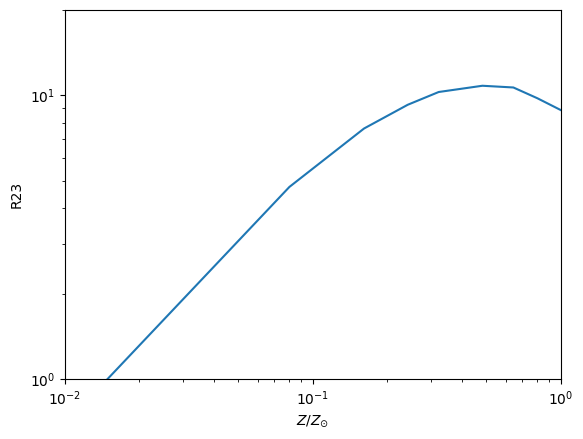

In [11]:
ratio_id = "R23"
ia = 0  # 1 Myr old for test grid
ratios = []
for iZ, Z in enumerate(grid.metallicity):
    grid_point = (ia, iZ)
    lines = grid.get_lines(grid_point)
    ratios.append(lines.get_ratio(ratio_id))

Zsun = grid.metallicity / 0.0124
plt.plot(Zsun, ratios)
plt.xlim([0.01, 1])
plt.ylim([1, 20])
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$Z/Z_{\odot}$")
plt.ylabel(rf"{ratio_id}")
# plt.ylabel(rf'${get_ratio_label(ratio_id)}$')
plt.show()

We can also generate diagrams using pairs of line ratios, such as the famous Baldwin, Phillips & Terlevich (BPT) diagram.

``line_ratios`` also contains some classification regions (e.g. [Kewley+13](https://ui.adsabs.harvard.edu/abs/2013ApJ...774L..10K/abstract) and [Kauffmann+03](https://ui.adsabs.harvard.edu/abs/2003MNRAS.346.1055K/abstract)) that we can plot:

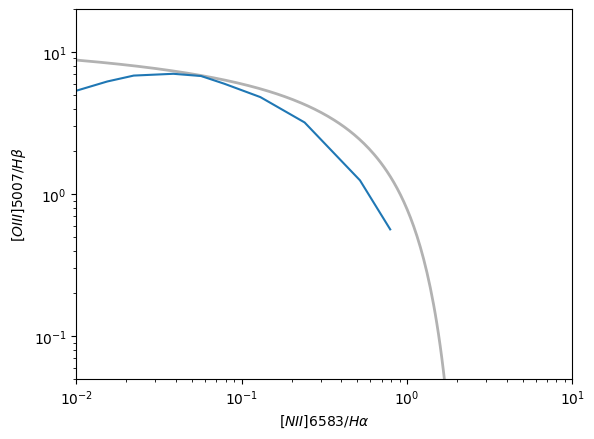

In [12]:
diagram_id = "BPT-NII"
ia = 0  # 1 Myr old for test grid
x = []
y = []
for iZ, Z in enumerate(grid.metallicity):
    grid_point = (ia, iZ)
    lines = grid.get_lines(grid_point)
    x_, y_ = lines.get_diagram(diagram_id)
    x.append(x_)
    y.append(y_)


# plot the Kewley SF/AGN dividing line

logNII_Ha = np.arange(-2.0, 1.0, 0.01)
logOIII_Hb = line_ratios.get_bpt_kewley01(logNII_Ha)
plt.plot(10**logNII_Ha, 10**logOIII_Hb, c="k", lw="2", alpha=0.3)

plt.plot(x, y)
plt.xlim([0.01, 10])
plt.ylim([0.05, 20])
plt.xscale("log")
plt.yscale("log")

# grab x and y labels, this time use "fancy" label ids
xlabel, ylabel = get_diagram_labels(diagram_id)

plt.xlabel(rf"${xlabel}$")
plt.ylabel(rf"${ylabel}$")
plt.show()